In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import nltk

In [4]:
nltk.download('punkt')

sns.set(style="whitegrid")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Roshan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [16]:
df = pd.read_csv(r"C:\Users\Roshan\Downloads\archive (6) - 1\sentimentdataset.csv")

In [17]:
print(df.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

          Timestamp            User     Platform  \
0  15-01-2023 12:30   User123          Twitter     
1  15-01-2023 08:45   CommuterX        Twitter     
2  15-01-2023 15:45   FitnessFan      Instagram    
3  15-01-2023 18:20   AdventureX       Facebook    
4  15-01-2023 19:55   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes       Country  \
0   #

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  732 non-null    int64 
 1   Unnamed: 0    732 non-null    int64 
 2   Text          732 non-null    object
 3   Sentiment     732 non-null    object
 4   Timestamp     732 non-null    object
 5   User          732 non-null    object
 6   Platform      732 non-null    object
 7   Hashtags      732 non-null    object
 8   Retweets      732 non-null    int64 
 9   Likes         732 non-null    int64 
 10  Country       732 non-null    object
 11  Year          732 non-null    int64 
 12  Month         732 non-null    int64 
 13  Day           732 non-null    int64 
 14  Hour          732 non-null    int64 
dtypes: int64(8), object(7)
memory usage: 85.9+ KB
None


In [19]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [20]:
df.dropna(inplace=True)


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df['Text'] = df['Text'].astype(str)

In [23]:
df['Clean_Text'] = df['Text'].str.lower()

print("\nDataset cleaned successfully.")
print(df.head())


Dataset cleaned successfully.
                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

          Timestamp            User     Platform  \
0  15-01-2023 12:30   User123          Twitter     
1  15-01-2023 08:45   CommuterX        Twitter     
2  15-01-2023 15:45   FitnessFan      Instagram    
3  15-01-2023 18:20   AdventureX       Facebook    
4  15-01-2023 19:55   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes       Country  \
0   #Nature #Park                                    15     30     USA         
1   #Traffic #Morning                                 5     10     Canada      
2

In [28]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

In [29]:
# Apply sentiment analysis
df['Polarity'] = df['Clean_Text'].apply(get_sentiment)

# Function to classify sentiment
def sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Create sentiment label column
df['Predicted_Sentiment'] = df['Polarity'].apply(sentiment_label)

print(df[['Clean_Text', 'Polarity', 'Predicted_Sentiment']].head())

                                          Clean_Text  Polarity  \
0   enjoying a beautiful day at the park!        ...  0.750000   
1   traffic was terrible this morning.           ... -1.000000   
2   just finished an amazing workout! 💪          ...  0.750000   
3   excited about the upcoming weekend getaway!  ...  0.468750   
4   trying out a new recipe for dinner tonight.  ...  0.136364   

  Predicted_Sentiment  
0            Positive  
1            Negative  
2            Positive  
3            Positive  
4            Positive  


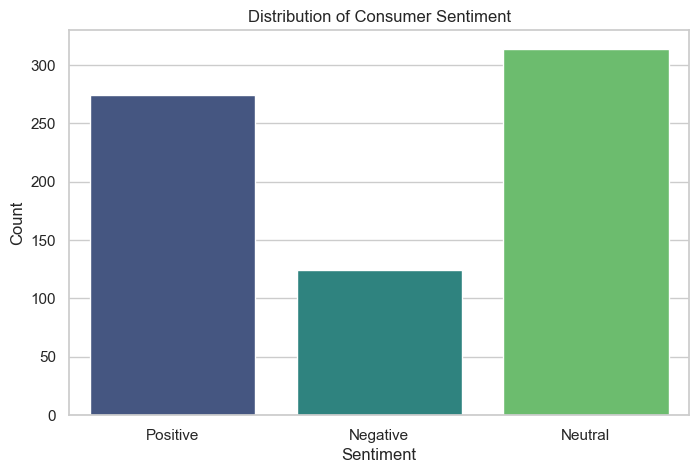

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Predicted_Sentiment',
    hue='Predicted_Sentiment',
    data=df,
    palette='viridis',
    legend=False
)

plt.title("Distribution of Consumer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

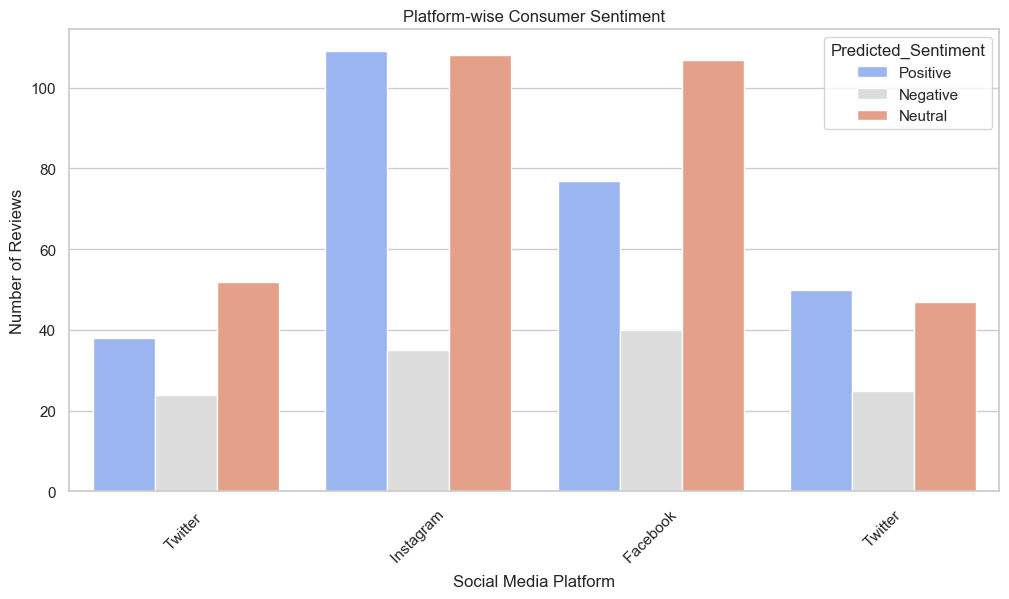

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Platform',
    hue='Predicted_Sentiment',
    data=df,
    palette='coolwarm'
)

plt.title("Platform-wise Consumer Sentiment")
plt.xlabel("Social Media Platform")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

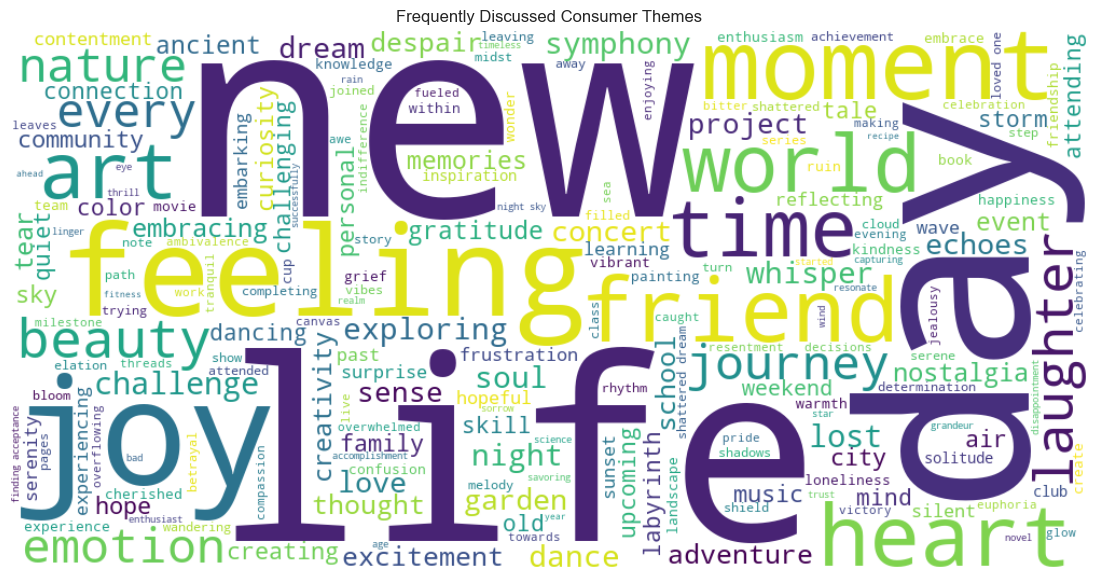

In [33]:
all_text = " ".join(df['Clean_Text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Frequently Discussed Consumer Themes")

plt.show()

In [34]:
keywords = [
    'trust',
    'algorithm',
    'recommend',
    'influence',
    'lifestyle',
    'addictive',
    'privacy',
    'ads',
    'shopping',
    'content'
]

keyword_counts = {}

for word in keywords:
    keyword_counts[word] = df['Clean_Text'].str.contains(word).sum()

keyword_df = pd.DataFrame({
    'Keyword': keyword_counts.keys(),
    'Count': keyword_counts.values()
})

print(keyword_df)

     Keyword  Count
0      trust      6
1  algorithm      0
2  recommend      1
3  influence      0
4  lifestyle      0
5  addictive      0
6    privacy      0
7        ads     11
8   shopping      1
9    content     10


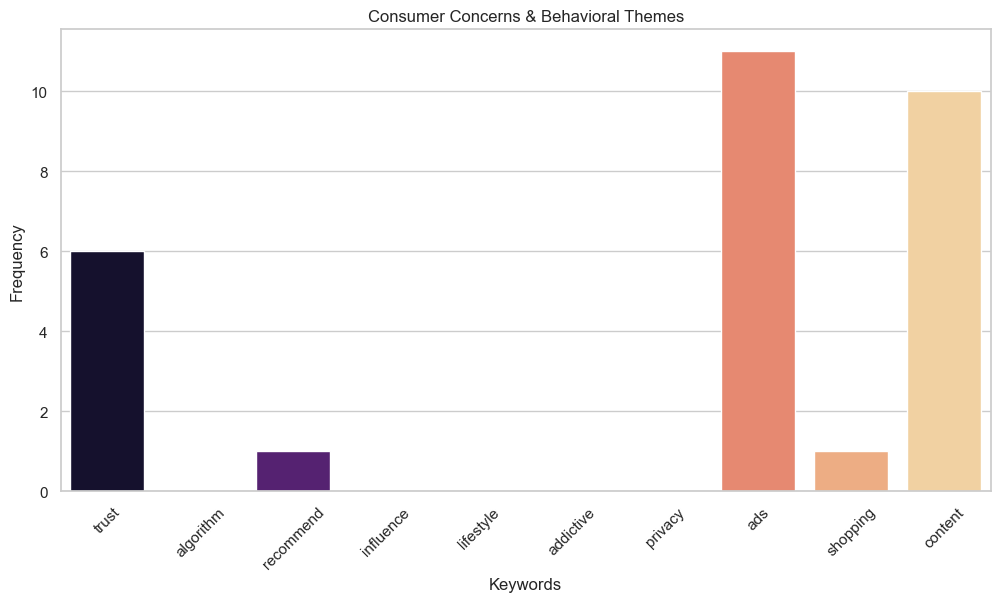

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Keyword',
    y='Count',
    hue='Keyword',
    data=keyword_df,
    palette='magma',
    legend=False
)

plt.title("Consumer Concerns & Behavioral Themes")
plt.xlabel("Keywords")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()